# MIT-BIH Arrhythmia Database: Federated Learning Simulation

This notebook simulates training our deep learning model in a **Federated Learning** context. We partition the heartbeat data among local client nodes based on Patient IDs, creating a realistic **Non-IID** distribution. We then implement a custom **Federated Averaging (FedAvg)** loop in PyTorch, aggregate local gradients over communication rounds, and compare the global model's performance against our centralized baseline.

In [ ]:
import sys, os
sys.path.append(str(pathlib.Path('.').resolve()))
# Helper to save figures in dated subfolders
def save_fig(fig, name, base_dir='assets'):
    import datetime, pathlib
    date_str = datetime.date.today().isoformat()
    target_dir = pathlib.Path(base_dir) / date_str
    target_dir.mkdir(parents=True, exist_ok=True)
    timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
    filename = f'{name}_{timestamp}.png'
    path = target_dir / filename
    fig.savefig(path, bbox_inches='tight')
    plt.close(fig)
    print(f'Figure saved to {path}')
    return str(path)
# Ensure base assets dir exists for compatibility
pathlib.Path('assets').mkdir(exist_ok=True)


## 1. Prerequisites and Setup

We import deep learning packages and create copies of state dicts to manage client weights.

In [1]:
import os
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

PARENT_DIR = os.getcwd().split("/")[-1]

PROCESSED_DIR = os.path.abspath("../../data/processed")
PROCESSED_DIR = os.path.join(PROCESSED_DIR, PARENT_DIR)

MODELS_DIR = os.path.abspath("../../models")
MODELS_DIR = os.path.join(MODELS_DIR, PARENT_DIR)

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
from mit_bih import save_plot


## 2. Defining the Shared Model Architecture

To aggregate weights, the central server and all local clients must share the exact same model architecture. We recreate our 1D CNN model here.

In [2]:
from mit_bih import ECGClassifier


## 3. Loading the Dataset & Simulating Patient Clients (Non-IID)

We load our segmented dataset and patient ID mappings. 

To keep execution fast for local execution, we select five patient records representing five distinct client hospitals. We split each client's data into local training (80%) and local testing (20%) datasets. The test sets are combined to create a global evaluation test set.

In [3]:
X = np.load(os.path.join(PROCESSED_DIR, "X.npy"))
y = np.load(os.path.join(PROCESSED_DIR, "y.npy"))
patient_ids = np.load(os.path.join(PROCESSED_DIR, "patient_ids.npy"))

# Select 5 patient IDs representing local clinical nodes
selected_patients = [100, 106, 119, 200, 207]
client_loaders = {}
global_test_x = []
global_test_y = []

for pid in selected_patients:
    idxs = np.where(patient_ids == pid)[0]
    X_p = X[idxs]
    y_p = y[idxs]
    
    # Split this patient's local data 80% train, 20% test
    split_idx = int(len(X_p) * 0.8)
    X_train_p, X_test_p = X_p[:split_idx], X_p[split_idx:]
    y_train_p, y_test_p = y_p[:split_idx], y_p[split_idx:]
    
    # Create local loader
    X_train_t = torch.tensor(X_train_p, dtype=torch.float32).unsqueeze(1)
    y_train_t = torch.tensor(y_train_p, dtype=torch.long)
    train_dataset = TensorDataset(X_train_t, y_train_t)
    client_loaders[pid] = DataLoader(train_dataset, batch_size=32, shuffle=True)
    
    # Save test set
    global_test_x.append(X_test_p)
    global_test_y.append(y_test_p)

# Construct unified global test loader
X_global_test = np.concatenate(global_test_x, axis=0)
y_global_test = np.concatenate(global_test_y, axis=0)
X_global_test_t = torch.tensor(X_global_test, dtype=torch.float32).unsqueeze(1)
y_global_test_t = torch.tensor(y_global_test, dtype=torch.long)
global_test_loader = DataLoader(TensorDataset(X_global_test_t, y_global_test_t), batch_size=256, shuffle=False)

print("Federated Client Setup:")
for pid in selected_patients:
    print(f"  Client {pid} (Patient): {len(client_loaders[pid].dataset)} local training samples")
print(f"\nGlobal Evaluation Test Set: {len(global_test_loader.dataset)} samples")

Federated Client Setup:
  Client 100 (Patient): 1816 local training samples
  Client 106 (Patient): 1621 local training samples
  Client 119 (Patient): 1589 local training samples
  Client 200 (Patient): 2080 local training samples
  Client 207 (Patient): 1487 local training samples

Global Evaluation Test Set: 2151 samples


## 4. Federated Averaging (FedAvg) Implementation

The standard **Federated Averaging (FedAvg)** algorithm aggregates local client updates via a weighted average:

$$W_{global} = \sum_{k=1}^{K} \frac{n_k}{N} W_k$$

where $n_k$ is the number of local training samples for client $k$, and $N$ is the total number of training samples across all participating clients.

In [4]:
from fl_core import federated_averaging


## 5. Local Training and Model Evaluation Routines

We define the functions for running gradient updates locally on client dataloaders and evaluating accuracies.

In [5]:
from fl_core import train_local_client, evaluate_model


## 6. Running the Federated Simulation

Let's initialize our global network model and train across **5 communication rounds**, performing **1 local epoch** of client updates per round.

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
global_model = ECGClassifier(num_classes=5).to(device)

num_rounds = 5
local_epochs = 1
round_accuracies = []

print("Starting Federated Simulation (FedAvg)...\n")
for r in range(num_rounds):
    client_weights = []
    client_sizes = []
    
    # Simulate each client downloading weights, training, and uploading updates
    for pid in selected_patients:
        local_model = copy.deepcopy(global_model)
        local_dict = train_local_client(
            local_model, 
            client_loaders[pid], 
            epochs=local_epochs
        )
        client_weights.append(local_dict)
        client_sizes.append(len(client_loaders[pid].dataset))
        
    # Aggregate parameters centrally on server
    new_global_weights = federated_averaging(global_model, client_weights, client_sizes)
    global_model.load_state_dict(new_global_weights)
    
    # Evaluate new global model state
    round_acc, _, _ = evaluate_model(global_model, global_test_loader)
    round_accuracies.append(round_acc)
    
    print(f"Communication Round {r+1:02d}/{num_rounds:02d} | Global Test Accuracy: {round_acc:.4f}")

Starting Federated Simulation (FedAvg)...



Communication Round 01/05 | Global Test Accuracy: 0.7146


Communication Round 02/05 | Global Test Accuracy: 0.8587


Communication Round 03/05 | Global Test Accuracy: 0.8656


Communication Round 04/05 | Global Test Accuracy: 0.8661


Communication Round 05/05 | Global Test Accuracy: 0.8656


## 7. Comparative Performance Analysis

Let's compare the global accuracy of our federated model against the centralized baseline model trained in Notebook 03.

In [7]:
# Load centralized weights for baseline comparison
centralized_model = ECGClassifier(num_classes=5).to(device)
cent_path = os.path.join(MODELS_DIR, "centralized_model.pth")

cent_acc = None
if os.path.exists(cent_path):
    centralized_model.load_state_dict(torch.load(cent_path, map_location=device))
    cent_acc, _, _ = evaluate_model(centralized_model, global_test_loader)
    print(f"Centralized Baseline Model Accuracy on client test sets: {cent_acc:.4f}")
else:
    print("Centralized baseline model state not found. Make sure to complete Notebook 03 first.")

# Final federated model classification performance
fed_acc, fed_labels, fed_preds = evaluate_model(global_model, global_test_loader)

print("\n" + "="*60)
print("FINAL ACCURACY SUMMARY ON CLIENT TEST DATA")
print("="*60)
if cent_acc is not None:
    print(f"Centralized Baseline Model Accuracy: {cent_acc:.4%}")
print(f"Federated Global Model Accuracy:     {fed_acc:.4%}")
print("="*60)

Centralized Baseline Model Accuracy on client test sets: 0.9675



FINAL ACCURACY SUMMARY ON CLIENT TEST DATA
Centralized Baseline Model Accuracy: 96.7457%
Federated Global Model Accuracy:     86.5644%


### Plotting Federated Accuracy over Communication Rounds

Saved figure to: /Users/bernard/Developer/FORKS/mit-bih/notebooks/01-mit-bih-arrhythmia/assets/federated_learning_accuracy_20260625_000609.png
Saved figure caption sidecar to: /Users/bernard/Developer/FORKS/mit-bih/notebooks/01-mit-bih-arrhythmia/assets/federated_learning_accuracy_20260625_000609.txt


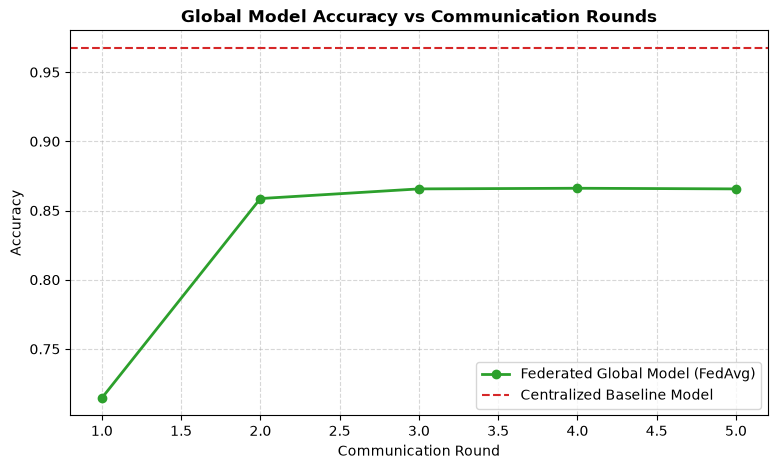

In [8]:
plt.figure(figsize=(9, 5))
plt.plot(range(1, num_rounds + 1), round_accuracies, marker='o', color='tab:green', linewidth=2, label="Federated Global Model (FedAvg)")
if cent_acc is not None:
    plt.axhline(y=cent_acc, color='tab:red', linestyle='--', linewidth=1.5, label="Centralized Baseline Model")
plt.title("Global Model Accuracy vs Communication Rounds", fontsize=12, fontweight='bold')
plt.xlabel("Communication Round")
plt.ylabel("Accuracy")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
save_plot("federated_learning_accuracy", caption="Line plot displaying federated global model accuracy over communication rounds, compared against the centralized baseline model.")
plt.show()

### Class-Level Breakdown (Federated Model)

Let's see if the federated model successfully classifies minority classes in our Non-IID client network.

In [9]:
print("Federated Model Classification Report:")
print(classification_report(fed_labels, fed_preds, labels=[0, 1, 2, 3, 4], target_names=['N', 'S', 'V', 'F', 'Q']))

Federated Model Classification Report:
              precision    recall  f1-score   support

           N       0.98      0.89      0.94      1481
           S       0.00      0.00      0.00       129
           V       0.67      1.00      0.80       541
           F       0.00      0.00      0.00         0
           Q       0.00      0.00      0.00         0

    accuracy                           0.87      2151
   macro avg       0.33      0.38      0.35      2151
weighted avg       0.84      0.87      0.85      2151



/Users/bernard/Developer/FORKS/mit-bih/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/bernard/Developer/FORKS/mit-bih/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/bernard/Developer/FORKS/mit-bih/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(a

## 8. Discussion: Challenges of Non-IID Medical Federated Learning

In a real-world setting, training models on patient-specific client nodes poses several challenges:

1. **Weight Divergence (Client Drift)**: When data is Non-IID (heterogeneous class distributions, different signal shapes), local model parameters update in conflicting directions. Aggregating them via simple FedAvg can lead to slower convergence or suboptimal performance compared to centralized learning.
2. **Minority Class Underrepresentation**: In an imbalanced setup, local client nodes might not see some minority categories at all. For example, patient 100 has zero Fusion (F) beats. During local training, patient 100's model learns to ignore or misclassify class F, which dilutes the global model's capacity on class F during aggregation.
3. **Proposed Mitigations**:
   - **FedProx**: Adds a proximal regularization term to local client objectives to prevent local weights from drifting too far from global weights.
   - **SCAFFOLD**: Uses control variates to correct client-drift conflicts during local updates.
   - **Synthetic Oversampling**: Using generative models (like GANs or VAEs) to augment minority classes locally on clinical client nodes before training.

## 9. Final Project Walkthrough and Conclusion

Congratulations! You have completed the full MIT-BIH Federated Learning pipeline:
1. **`01_exploratory_data_analysis.ipynb`**: Explored signal records, annotations, andmapped beat symbols to standard AAMI classes.
2. **`02_data_preprocessing_and_segmentation.ipynb`**: Noise-filtered raw ECG streams, segmented individual heartbeats around R-peaks, and Z-score normalized segments.
3. **`03_local_model_training.ipynb`**: Developed a 1D CNN in PyTorch and established a centralized baseline.
4. **`04_federated_learning_simulation.ipynb`**: Simulated an FL network on heterogeneous patient data using FedAvg weight aggregation, comparing accuracy against the centralized baseline.

This workflow showcases how medical sites can collaboratively train deep learning models without sharing sensitive patient health records!